# Company finances and later stock prices

## 1. Research question and context
**Among the companies in this dataset, are positive revenue growth and positive profit margins associated with a higher percentage of stock-price increases in calendar year t+2?** Financial years are 2014–2017 and outcome years are 2016–2019.

Revenue describes company sales, while profit describes what remains after expenses. These measures may be related to later stock performance, but a simple relationship does not establish causation or reliable prediction. The hypotheses are that companies with positive revenue growth and companies with positive profit margins have higher later increase rates than their respective nonpositive groups.

This is a simpler exploratory version of the earlier stock project. It uses loops, basic pandas commands, and matplotlib. It does not fit the earlier forecasting models.

## 2. Dataset and API collection
The source is *200+ financial indicators of US stocks (2014–2018)* on Kaggle (Carbone, n.d.). The prior project downloaded the ZIP through Kaggle's public dataset-download API on September 9, 2026, Eastern time. This project reuses that exact archive. The code below downloads it only if it is missing. It does not scrape webpages or bypass access controls. If the API denies access, use Kaggle's official access process.

The original five CSV files contain **22,077 rows, 4,980 distinct ticker strings, and 225 columns per file**. The unit of analysis is a company-year, identified by ticker and financial year. The provider describes the underlying financial data as coming from Financial Modeling Prep. This is a secondary dataset, not a direct SEC extraction. We select sales, growth, profits, EPS, valuation, debt, equity, company size, sector, and price change.

After the later-year match, there are **17,063 rows and 4,847 tickers**. Missing predictor values remain missing. The code prints a complete missing-value table, including percentages, after cleaning. These counts describe the included archive; reruns on a revised source could differ.

In [1]:
import os
import urllib.request
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

api_url = "https://www.kaggle.com/api/v1/datasets/download/cnic92/200-financial-indicators-of-us-stocks-20142018"
archive_name = "original_financial_data.zip"

# Reuse the API download so we do not send unnecessary requests.
if not os.path.exists(archive_name):
    urllib.request.urlretrieve(api_url, archive_name)

tables = []
with zipfile.ZipFile(archive_name) as archive:
    for year in range(2014, 2019):
        file_name = str(year) + "_Financial_Data.csv"
        table = pd.read_csv(archive.open(file_name))
        print(year, "rows:", len(table), "columns:", len(table.columns))
        table = table.rename(columns={table.columns[0]: "ticker"}).copy()
        table["financial_year"] = year
        table["outcome_year"] = year + 1
        table["price_change_pct"] = table[str(year + 1) + " PRICE VAR [%]"]
        tables.append(table)

raw = pd.concat(tables, ignore_index=True)
print("Original rows:", len(raw))
print("Original tickers:", raw["ticker"].nunique())

2014 rows: 3808 columns: 225
2015 rows: 4120 columns: 225
2016 rows: 4797 columns: 225
2017 rows: 4960 columns: 225
2018 rows: 4392 columns: 225
Original rows: 22077
Original tickers: 4980


## 3. Conceptualized and operationalized variables

| Variable | Concept and role | Measurement in this project |
|---|---|---|
| Stock-price increase | Later performance; dependent variable | 1 if supplied calendar-year price change is greater than 0%; otherwise 0. A zero return is a non-increase. |
| Revenue growth | Change in sales; main independent variable | Vendor's `Revenue Growth`, treated as a fractional growth measure; group into greater than zero versus zero or below. Its precise vendor convention is not independently verified. |
| Profit margin | Profitability; main independent variable | Net income / revenue when revenue is positive; group into positive versus zero or below. |
| Net income growth | Change in profit; retained independent variable | Vendor's `Net Income Growth`; changes involving losses are difficult to interpret. |
| EPS | Profit per share; retained independent variable | Supplied `EPS`, in reported monetary units per share. |
| P/E | Valuation relative to earnings; retained independent variable | Supplied `PE ratio`; historical timing and handling of losses are unverified. |
| Debt-to-equity | Financial leverage; retained independent variable | Total debt / positive shareholder equity. Nonpositive equity gives a missing ratio. |
| ROE | Profitability relative to equity; retained independent variable | Net income / positive ending shareholder equity. This does not use average equity. |
| Market capitalization | Company size; potential control | Supplied `Market Cap`, in vendor monetary units. |
| Sector | Business category; potential control | Supplied `Sector`. Retained but not statistically controlled in these charts. |

Financial year t is paired with the annual price change in t+2. For example, 2014 finances are paired with the 2016 annual price change. This leaves an intervening year for financial reports to appear; it is not a cumulative two-year return. Exact publication dates and later revisions are unavailable, so the lag does not prove that every feature was available in real time. Trading volume and a verified past-return predictor are omitted because they were not available in the earlier prepared dataset.

## 4. Cleaning and preparation
First, select a manageable set of columns. Trim whitespace from ticker names so matching is consistent. Convert numeric columns with `errors="coerce"`: text that cannot be interpreted as a number becomes missing. Replace positive and negative infinity with missing values. Stop if duplicate company-year keys or missing tickers appear, since guessing which company record to keep could make the match incorrect.

In [2]:
columns = ["ticker", "financial_year", "outcome_year", "Revenue",
           "Revenue Growth", "Net Income", "Net Income Growth", "EPS",
           "PE ratio", "Total debt", "Total shareholders equity", "Market Cap",
           "Sector", "price_change_pct"]
data = raw[columns].copy()
data["ticker"] = data["ticker"].astype("string").str.strip()
data["ticker"] = data["ticker"].replace("", pd.NA)

for column in data.columns:
    if column not in ["ticker", "Sector"]:
        data[column] = pd.to_numeric(data[column], errors="coerce")
        data[column] = data[column].replace([float("inf"), -float("inf")], float("nan"))

print("Duplicate company-years:", data.duplicated(["ticker", "financial_year"]).sum())
if data["ticker"].isna().any():
    raise ValueError("Review missing tickers before matching.")
if data.duplicated(["ticker", "financial_year"]).any():
    raise ValueError("Review duplicate company-years before matching.")

positive_equity = data["Total shareholders equity"].where(data["Total shareholders equity"] > 0)
positive_revenue = data["Revenue"].where(data["Revenue"] > 0)
data["debt_to_equity"] = data["Total debt"] / positive_equity
data["roe"] = data["Net Income"] / positive_equity
data["profit_margin"] = data["Net Income"] / positive_revenue

Duplicate company-years: 0


Ratios with zero or negative denominators are left missing because they can be undefined or hard to compare. Negative net income is retained: a loss is real information. These rules increase ratio missingness and omit some financially distressed firms from ratio comparisons.

Next, separate the original outcomes from the financial variables and match each financial year to t+2. A left join lets us count unmatched rows before removing them. Only rows missing the outcome are removed. We do not fill missing predictors with zero because “unknown” and “zero” mean different things. The supplied `Class` field is not used; the earlier audit found 25 zero-return rows marked as increases, so the outcome is recomputed.

In [3]:
outcomes = data[["ticker", "outcome_year", "price_change_pct"]].copy()
features = data.drop(columns=["outcome_year", "price_change_pct"]).copy()
features["outcome_year"] = features["financial_year"] + 2

stocks = pd.merge(features, outcomes, on=["ticker", "outcome_year"],
                  how="left", validate="one_to_one")
excluded = stocks[stocks["price_change_pct"].isna()]
print("Rows excluded because the later outcome is missing:", len(excluded))
excluded[["ticker", "financial_year", "outcome_year"]].to_csv("excluded_rows.csv", index=False)
stocks = stocks.dropna(subset=["price_change_pct"]).copy()
stocks["price_increased"] = (stocks["price_change_pct"] > 0).astype(int)

missing = pd.DataFrame()
missing["missing_count"] = stocks.isna().sum()
missing["missing_percent"] = stocks.isna().mean() * 100
print("Prepared rows:", len(stocks))
print("Prepared tickers:", stocks["ticker"].nunique())
print(missing.round(2).to_string())
print("Rows by outcome year:")
print(stocks.groupby("outcome_year").size().to_string())
missing.to_csv("missing_values.csv")
stocks.to_csv("cleaned_stock_data.csv", index=False)

Rows excluded because the later outcome is missing: 5014
Prepared rows: 17063
Prepared tickers: 4847
                           missing_count  missing_percent
ticker                                 0             0.00
financial_year                         0             0.00
Revenue                              656             3.84
Revenue Growth                      1365             8.00
Net Income                           961             5.63
Net Income Growth                   1564             9.17
EPS                                  772             4.52
PE ratio                            1412             8.28
Total debt                          1061             6.22
Total shareholders equity            806             4.72
Market Cap                          2059            12.07
Sector                                 0             0.00
debt_to_equity                      2040            11.96
roe                                 1983            11.62
profit_margin                

The 5,014 excluded rows include the 2018 financial cohort, whose required 2020 outcome is unavailable. They also include companies that cannot be matched to a later outcome. This can favor surviving firms. The retained dataset has 9,630 increases and 7,433 non-increases. Revenue growth is missing in 1,365 rows (8.00%) and profit margin in 1,792 rows (10.50%). Each chart drops only the values it needs; the groups can therefore describe different subsets. Extreme values remain in the dataset. The charts use sign groups instead of silently trimming outliers.

## 5. Visualization 1: Revenue growth and later increases
This bar chart compares the percentage of later price increases for companies with positive revenue growth versus zero or negative growth. Each company-year contributes once. A higher positive-growth bar would support the first descriptive hypothesis. Missing revenue growth is excluded, not classified as nonpositive.

Increase rate (%):
growth_group
Zero or negative    50.11
Positive            61.06
Company-years in each group:
growth_group
Zero or negative     5448
Positive            10250


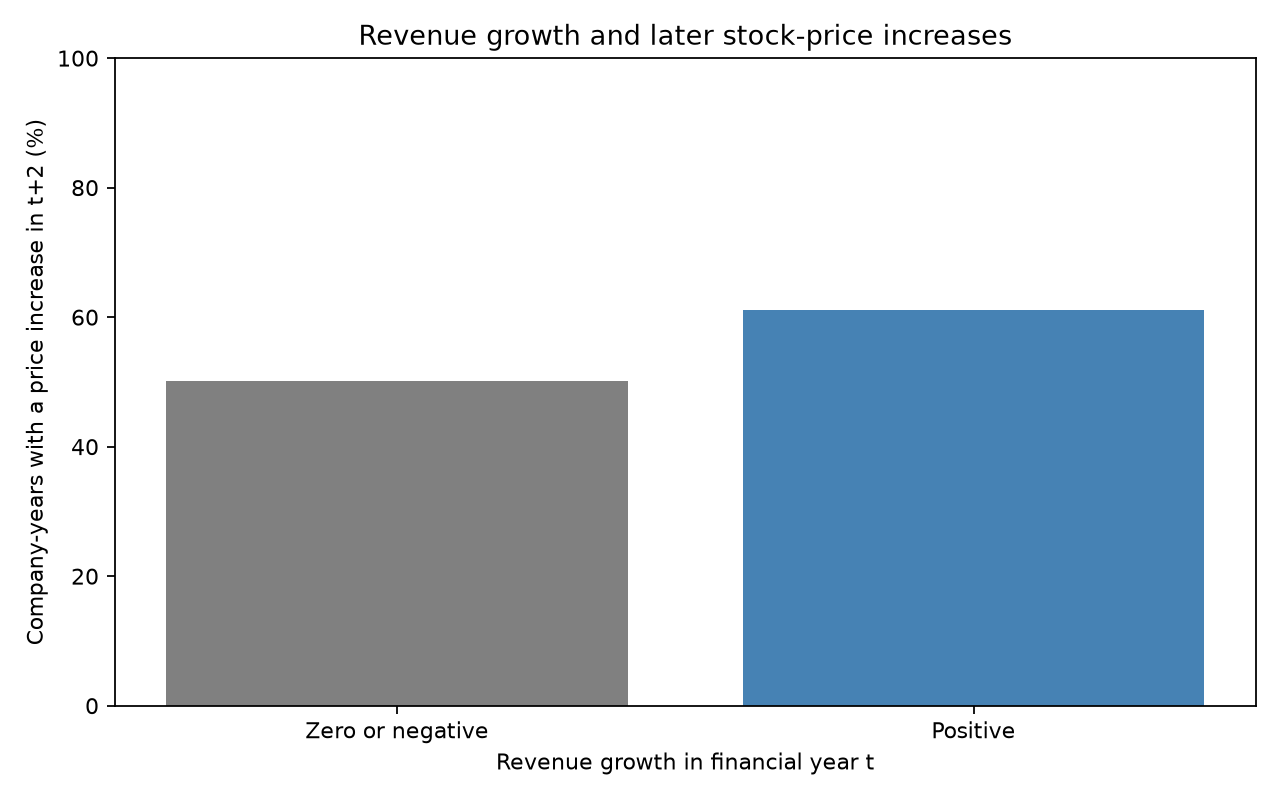

In [4]:
growth = stocks.dropna(subset=["Revenue Growth"]).copy()
growth["growth_group"] = "Zero or negative"
growth.loc[growth["Revenue Growth"] > 0, "growth_group"] = "Positive"
growth_rates = growth.groupby("growth_group")["price_increased"].mean() * 100
growth_rates = growth_rates.reindex(["Zero or negative", "Positive"])
growth_counts = growth.groupby("growth_group").size().reindex(growth_rates.index)
print("Increase rate (%):")
print(growth_rates.round(2).to_string())
print("Company-years in each group:")
print(growth_counts.to_string())

plt.figure(figsize=(8, 5))
plt.bar(growth_rates.index, growth_rates.values, color=["gray", "steelblue"])
plt.title("Revenue growth and later stock-price increases")
plt.xlabel("Revenue growth in financial year t")
plt.ylabel("Company-years with a price increase in t+2 (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("revenue_growth_chart.png", dpi=160)
plt.show()

## 6. Visualization 2: Profit margin across outcome years
This line chart compares later increase rates for positive-margin and nonpositive-margin company-years separately in each outcome year. The y-axis is a percentage of company-years, not the size of their returns. The lines connect yearly group summaries, not the same fixed set of companies. This checks whether the profitability pattern appears consistently across the four years instead of relying only on a pooled average.

Increase rates (%):
profit_group  Positive  Zero or negative
outcome_year                            
2016             78.91             51.79
2017             70.69             54.09
2018             29.14             27.36
2019             76.90             53.20
Company-years in each group:
profit_group  Positive  Zero or negative
outcome_year                            
2016              2608               948
2017              2559              1198
2018              2673              1290
2019              2745              1250


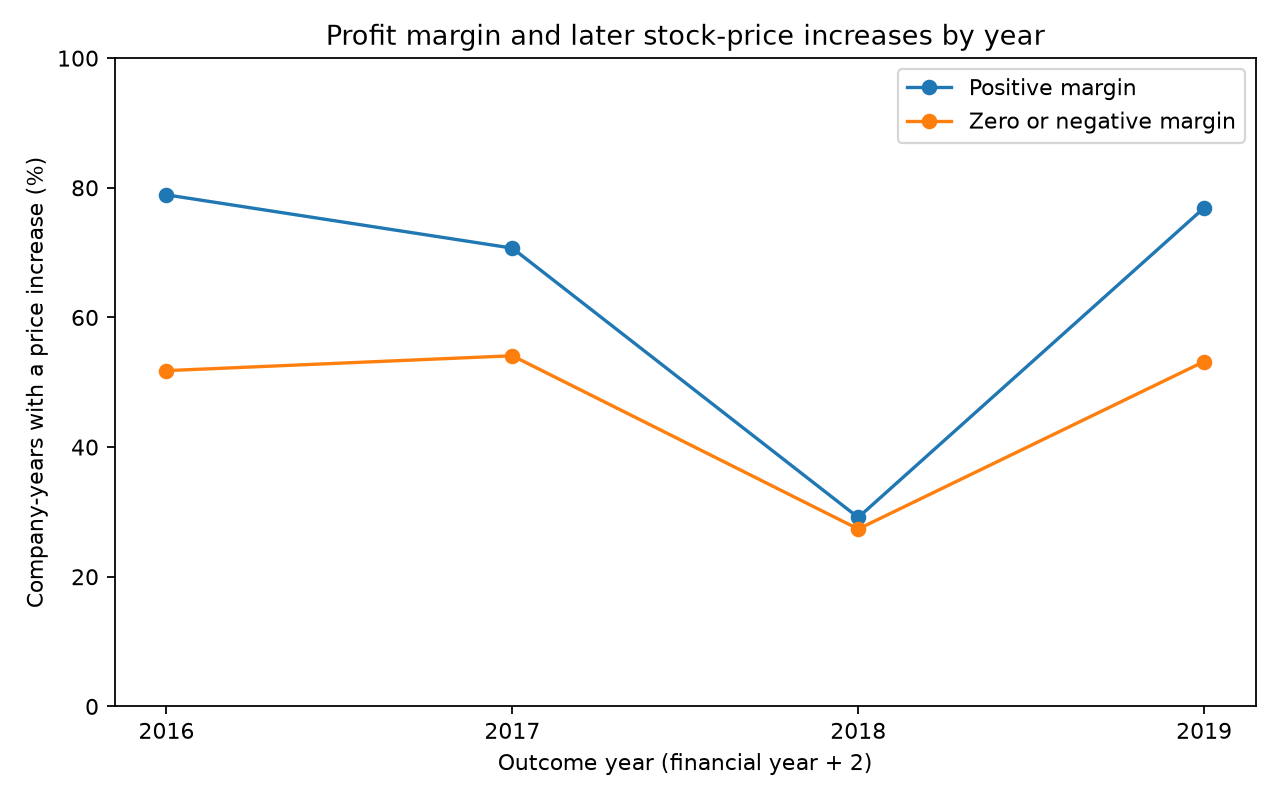

In [5]:
profit = stocks.dropna(subset=["profit_margin"]).copy()
profit["profit_group"] = "Zero or negative"
profit.loc[profit["profit_margin"] > 0, "profit_group"] = "Positive"
profit_rates = profit.groupby(["outcome_year", "profit_group"])["price_increased"].mean().unstack() * 100
profit_counts = profit.groupby(["outcome_year", "profit_group"]).size().unstack()
print("Increase rates (%):")
print(profit_rates.round(2).to_string())
print("Company-years in each group:")
print(profit_counts.to_string())

plt.figure(figsize=(8, 5))
plt.plot(profit_rates.index, profit_rates["Positive"], marker="o", label="Positive margin")
plt.plot(profit_rates.index, profit_rates["Zero or negative"], marker="o", label="Zero or negative margin")
plt.title("Profit margin and later stock-price increases by year")
plt.xlabel("Outcome year (financial year + 2)")
plt.ylabel("Company-years with a price increase (%)")
plt.xticks([2016, 2017, 2018, 2019])
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.savefig("profit_margin_chart.png", dpi=160)
plt.show()

## 7. Results
In the included data, the later increase rate is **61.06% for positive revenue growth** and **50.11% for zero or negative growth**, a difference of **10.95 percentage points**. This supports the first descriptive hypothesis in the pooled sample. Positive-margin firms have higher increase rates in all four outcome years, supporting the second descriptive hypothesis in this sample. However, the margin-group gap ranges from only **1.78 percentage points in 2018** to **27.12 in 2016**. Both groups have much lower increase rates in 2018 than in the other observed years, so the annual context matters. These comparisons do not establish causality or predictive accuracy.

The next cell reports the measured differences. A percentage-point difference compares two rates; it is not a stock return or a forecast. These are descriptive comparisons, without a causal test or out-of-sample prediction evaluation.

In [6]:
difference = growth_rates["Positive"] - growth_rates["Zero or negative"]
print("Positive revenue-growth increase rate:", round(growth_rates["Positive"], 2), "%")
print("Nonpositive revenue-growth increase rate:", round(growth_rates["Zero or negative"], 2), "%")
print("Difference:", round(difference, 2), "percentage points")
if difference > 0:
    print("The pooled revenue-growth comparison supports the first descriptive hypothesis.")
else:
    print("The pooled revenue-growth comparison does not support the first descriptive hypothesis.")

margin_differences = profit_rates["Positive"] - profit_rates["Zero or negative"]
print("Positive minus nonpositive margin differences, in percentage points:")
print(margin_differences.round(2).to_string())
print("Years with a higher increase rate for positive margins:", int((margin_differences > 0).sum()), "out of", len(margin_differences))

Positive revenue-growth increase rate: 61.06 %
Nonpositive revenue-growth increase rate: 50.11 %
Difference: 10.95 percentage points
The pooled revenue-growth comparison supports the first descriptive hypothesis.
Positive minus nonpositive margin differences, in percentage points:
outcome_year
2016    27.12
2017    16.60
2018     1.78
2019    23.70
Years with a higher increase rate for positive margins: 4 out of 4


## 8. Ethics and limitations
- **Responsible collection:** The archive was obtained through the public Kaggle API and is cached. No HTML scraping, personal data collection, or excessive requests are involved. Public access does not establish unrestricted redistribution rights. The earlier source record lists “Data files © Original Authors”; check the source terms before publishing the raw data.
- **Coverage bias:** This is a convenience sample, not a verified historical list of every US stock. Missing companies, delistings, ticker changes, and the later-year join may favor surviving companies. Ticker strings are imperfect company identifiers.
- **Missing data:** Firms with missing growth or margin are absent from that particular chart. Their missingness may be related to financial distress or reporting differences. Group counts are printed so this selection is visible.
- **Missing context:** Sector, company size, market conditions, interest rates, and investor expectations could explain differences. These charts do not adjust for those factors. Grouping values by sign also loses information about magnitude.
- **Measurement:** Vendor growth conventions, currency consistency, historical valuation dates, dividends, splits, and revisions have not been independently verified. The outcome is a supplied price-change measure, not verified total shareholder return.
- **Timing and dependence:** A full intervening year reduces one reporting-delay concern but does not establish point-in-time validity. Companies recur across years and share market shocks. Thousands of company-years do not mean thousands of independent market periods.
- **Unanswered questions:** Would these patterns persist in a newer period, within sectors, after accounting for company size, or in firms missing from this source? Could a model outperform a simple baseline on later data? This project does not answer those questions or establish an investment strategy.

## 9. References
Carbone, N. (n.d.). *200+ financial indicators of US stocks (2014–2018)* [Data set]. Kaggle. https://www.kaggle.com/datasets/cnic92/200-financial-indicators-of-us-stocks-20142018

The dataset citation supplies the source context; the definitions and cleaning rules above are the project's own operational choices. Original collection details and checksum are preserved in `original_collection_summary.json`.

AI assistance: OpenAI Codex helped simplify and execute the code and draft the explanations. Review the code and results and follow your course's disclosure requirements.